In [1]:
import numpy as np
import math as math
import matplotlib.pylab as plt
import matplotlib as mpl
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.tri as tri
import matplotlib.patches as mpatches
from scipy.special import factorial, gamma, digamma, ellipk, ellipe, hyp2f1
import mpmath as mp
from scipy.integrate import quad,trapezoid
from numpy import vectorize
from scipy.optimize import fsolve, bisect, newton

## Fox $H$-functions  $\longrightarrow$  Meijer $G$-function representation

In order to verify that the power series that we provided for the Fox $H$-function are correct, we compare such power series with the corresponding Meijer G-function representation. We use the implementation of the in the Meijer G-function given in the library mpmath (it is quite slow particularly for x^2 > 1).

In [2]:
# Meijer G-function representation

# For the surface mass density
def SMDg(x, n):
    if x**2 != 1:
        return ((2**(n-3))/np.pi)*mp.meijerg([[1-n/2, (1-n)/2],[]], [[-1/2,-1/2],[]], x**2).real
    if x**2 == 1:
        return gamma(n-1)**2/(2**(n - 1)*gamma(n - 1/2))
# For the projected mass
def PMg(x, n):
    if x**2 != 1:
        return ((2**(n-3))/np.pi)*mp.meijerg([[1-n/2, (1-n)/2, -1/2],[]], [[-1/2,-1/2],[-3/2]], x**2).real
    if x**2 == 1:
        return (2*gamma(n - 3)/np.sqrt(np.pi))*(1 - (np.sqrt(np.pi)*gamma(n - 1)/(2**(n - 3)*gamma(n - 3/2))))
# For the deflection potential
def DPg(x, n):
    if x**2 != 1:
        return ((2**(n-3))/np.pi)*mp.meijerg([[1-n/2, (1-n)/2, -1/2, -1/2],[]], [[-1/2,-1/2],[-3/2,-3/2]], x**2).real
    if x**2 == 1:
        return (2*gamma(n - 3)/np.sqrt(np.pi))*(1 - (np.sqrt(np.pi)*gamma(n - 1)/(2**(n - 3)*gamma(n - 3/2))))

## Fox $H$-functions - power series
Here, we describe how to compute each of the three Fox $H$-functions that allows to describe the gNFW as a gravitational lens. In particular, we do this by means of their power series representations.

### Recursive implementation

#### $H^{2,1}_{2,2\,\Sigma}\left(x^2,n\right)$ (Surface mass density)

Here, we have the power (logarithmic) series representation for the Fox $H$-function
$$
H^{2,1}_{2,2\,\Sigma}\left(x^2,n\right) = 
H_{2,2}^{2,1} \!\left[ x^2 \left| \begin{matrix}
( 1-n , 2 ),( 0 , 1 ) \\
( -1 , 2 ),( -\frac{1}{2} , 1 ) \end{matrix} \right. \right].
$$

**For $0<x^2<1$ ($n>2$):**

$$
\begin{equation}
\dfrac{2^{n-3}}{\pi|x|}\sum_{k=0}^{\infty}\Gamma\left(\frac{n-1}{2}+k\right)\Gamma\left(\frac{n}{2}+k\right)\dfrac{x^{2k}}{(k!)^2}\Bigg[2\psi_{0}(1+k)
-\psi_{0}\left(\dfrac{n-1}{2}+k\right)-\psi_{0}\left(\dfrac{n}{2}+k\right)-\ln\left(x^2\right)\Bigg]
\end{equation}
$$
This power series can be written recursively as 
$$
\begin{equation}
\dfrac{2^{n-3}}{\pi|x|}\sum_{k=0}^{\infty}a_{1,k}x^{2k}\left[a_{2,k}-\ln\left(x^2\right)\right],
\end{equation}
$$
where
$$
\begin{align}
a_{1,k} = 
\begin{dcases}
\Gamma\left(\dfrac{n-1}{2}\right)\Gamma\left(\dfrac{n}{2}\right)\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 3)(2k + n - 2)}{4k^2}a_{1,k-1}\quad & \text{if } k>0
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{2,k} = 
\begin{dcases}
2\psi_{0}(1)-\psi_0\left(\dfrac{n-1}{2}\right) - \psi_0\left(\dfrac{n}{2}\right)\quad & \text{if } k=0 \\[3 mm]
\dfrac{2}{k} - \dfrac{2}{2k + n - 3} - \dfrac{2}{2k + n - 2} + a_{2,k-1} \quad & \text{if } k>0
\end{dcases}.
\end{align}
$$

<br/><br/>
**For $x^2>1$ ($n>2$):**

$$
\begin{align}
\frac{1}{2}\sum_{k=0}^{\infty}\dfrac{(-1)^{k}}{k!}\dfrac{\Gamma\left(n-1+k\right)\Gamma\left(\frac{n-1+k}{2}\right)}{\Gamma\left(\frac{n+k}{2}\right)}|x|^{-(k+n)} = 
\dfrac{1}{2|x|^n}\sum_{k=0}^{\infty}\dfrac{\Gamma\left(n-1+2k\right)\Gamma\left(\frac{n-1}{2}+k\right)}{\Gamma\left(\frac{n}{2}+k\right)}\dfrac{x^{-2k}}{(2k)!}-
\dfrac{1}{2|x|^{n+1}}\sum_{k=0}^{\infty}\dfrac{\Gamma\left(n+2k\right)\Gamma\left(\frac{n}{2}+k\right)}{\Gamma\left(\frac{n+1}{2}+k\right)}\dfrac{x^{-2k}}{(2k+1)!}
\end{align}
$$

The last step allows us to write the series in a recursive way as 

$$
\begin{align}
\dfrac{1}{2|x|^{n+1}}\sum_{k=0}^{\infty}\left(|x|a_{3,k}-a_{4,k}\right)x^{-2k}
\end{align}
$$
with
$$
\begin{align}
a_{3,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n-1\right)\Gamma\left(\frac{n-1}{2}\right)}{\Gamma\left(\frac{n}{2}\right)}\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 3)^2}{2k(2k-1)}a_{3,k-1}\quad & \text{if } k>0
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{4,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n\right)\Gamma\left(\frac{n}{2}\right)}{\Gamma\left(\frac{n+1}{2}\right)}\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 2)^2}{2k(2k+1)}a_{4,k-1}\quad & \text{if } k>0
\end{dcases}.
\end{align}
$$


In [3]:
# Fox H-function power series
def SMDh(x, n, tol, N_max = 10000000):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    n: profile
    N_max : maximun number of iterations
    """
    
    sk =  np.ones(4)
    ck =  np.ones(4)
    
    if 0 < x**2 < 1: 
        a1k = gamma((n - 1)/2)*gamma(n/2)
        a2k = 2*digamma(1) - digamma((n - 1)/2) - digamma(n/2)
        aux  = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))
        ck[0] = aux
        sk[0] = aux 
        

        for k in range(1, N_max):
            a1k *= (2*k + n - 3)*(2*k + n -2)/(4*k**2)
            a2k += 2/k - 2/(2*k + n - 3) - 2/(2*k + n -2)

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))*x**(2*k)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0]


    if x**2 > 1:
        a3k = gamma(n - 1)*gamma((n - 1)/2)/gamma(n/2)
        a4k = gamma(n)*gamma(n/2)/gamma((n + 1)/2)
        aux = 0.5*(np.abs(x)*a3k - a4k)/(np.abs(x)**(n + 1))
        ck[0] = aux
        sk[0] = aux
        
        for k in range(1, N_max):
            a3k *= (2*k + n - 3)**2/(2*k*(2*k - 1))
            a4k *= (2*k + n - 2)**2/(2*k*(2*k + 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = 0.5*((np.abs(x)*a3k - a4k)*(x**(-2*k)))/(np.abs(x)**(n + 1))
            ck[0] = aux
            sk[0] += aux
            
            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0]

In [4]:
points = 100
tol = 1e-10

n = 7/2

x = np.linspace(0.01, 5, points)

h_smd_s = np.zeros(points)
h_smd_g = np.zeros(points)

for i in range(points):
    h_smd_g[i] = SMDg(x[i], n) # Meijer G-function
    terms, smdi = SMDh(x[i], n, tol) # Fox H-function power series
    h_smd_s[i] = smdi
    
"""
Relative porcentual difference: 
The biggest difference tends to happen close to x = 1, where the Fox H-function has a discontinuity.
"""
print(np.amax(np.abs(100*(h_smd_g - h_smd_s)/h_smd_g)))

2.621393751741767e-07


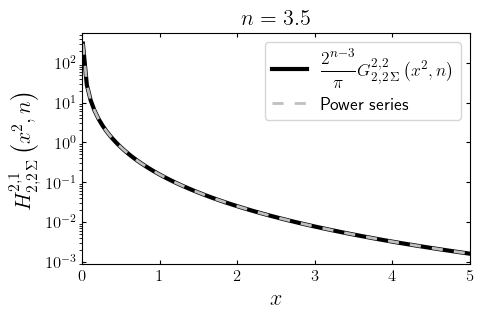

In [5]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
ls = 3
lc = 2

colora = "black"
colorn = "silver"

fig = plt.figure(figsize=(5, 3))
ges = GridSpec(1, 1)
ax1 = fig.add_subplot(ges[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.plot(x, h_smd_g, color =  colora, linestyle = "-", label = r"$\dfrac{2^{n-3}}{\pi}G^{2,2}_{2,2\,\Sigma}\left(x^2,n\right)$", linewidth = ls)
ax1.plot(x, h_smd_s, color = colorn, linestyle = (0,(4,4)), label = r"Power series", linewidth = lc)

ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$H^{2,1}_{2,2\,\Sigma}\left(x^2,n\right)$", fontsize=axis_fs)
ax1.set_title(r"$n = {0}$".format(*[n]), fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax1.set_xlim(0, 5)
#ax1.set_ylim(0, 2)
ax1.set_yscale("log")

ax1.legend(loc='upper right', fontsize = 0.8*axis_fs)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("power_series_smd.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

#### $H^{2,2}_{3,3\,M}\left(x^2,n\right)$ (Projected mass)

Here we have the power (logarithmic) series representation for the Fox $H$-function
$$
H^{2,2}_{3,3\,M}\left(x^2,n\right)=
H^{2,2}_{3,3} \!\left[ x^2 \left| \begin{matrix}
(1-n,2), ( -\frac{1}{2} , 1 ), (0, 1) \\
( -1 , 2 ),( -\frac{1}{2} , 1), (-\frac{3}{2}, 1) \end{matrix} \right. \right].
$$

**For $0<x^2<1$ ($n>2$):**

$$
\begin{equation}
\dfrac{2^{n-3}}{\pi|x|}\sum_{k=0}^{\infty}\Gamma\left(\frac{n-1}{2}+k\right)\Gamma\left(\frac{n}{2}+k\right)\dfrac{x^{2k}}{k!(k+1)!}\Bigg[\psi_{0}(1+k) + \psi_{0}(2+k) 
-\psi_{0}\left(\dfrac{n-1}{2}+k\right)-\psi_{0}\left(\dfrac{n}{2}+k\right)-\ln\left(x^2\right)\Bigg]
\end{equation}
$$
This power series can be written recursively as 
$$
\begin{equation}
\dfrac{2^{n-3}}{\pi|x|}\sum_{k=0}^{\infty}a_{1,k}x^{2k}\left[a_{2,k}-\ln\left(x^2\right)\right],
\end{equation}
$$
where
$$
\begin{align}
a_{1,k} = 
\begin{dcases}
\Gamma\left(\dfrac{n-1}{2}\right)\Gamma\left(\dfrac{n}{2}\right)\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 3)(2k + n - 2)}{4k(k+1)}a_{1,k-1}\quad & \text{if } k>0
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{2,k} = 
\begin{dcases}
1+2\psi_{0}(1)-\psi_0\left(\dfrac{n-1}{2}\right) - \psi_0\left(\dfrac{n}{2}\right)\quad & \text{if } k=0 \\[3 mm]
\dfrac{1}{k} + \dfrac{1}{1+k} - \dfrac{2}{2k + n - 3} - \dfrac{2}{2k + n - 2} + a_{2,k-1} \quad & \text{if } k>0
\end{dcases}.
\end{align}
$$

<br/><br/>
**For $x^2>1$ ($n>2$ and $n\notin \mathbb{Z}$):**

$$
\begin{multline}
\sum_{k=0}^{\infty}\dfrac{(-1)^{k}}{k!}\dfrac{\Gamma\left(n-1+k\right)\Gamma\left(\frac{n-1+k}{2}\right)}{\Gamma\left(\frac{n+k}{2}\right)}\dfrac{|x|^{-(k+n)}}{(3-n-k)} + \dfrac{2\Gamma(n-3)}{\sqrt{\pi}|x|^3} \\= 
\dfrac{1}{|x|^n}\sum_{k=0}^{\infty}\dfrac{\Gamma\left(n-1+2k\right)\Gamma\left(\frac{n-1}{2}+k\right)}{\Gamma\left(\frac{n}{2}+k\right)}\dfrac{x^{-2k}}{(3-n-2k)(2k)!}-
\dfrac{1}{|x|^{n+1}}\sum_{k=0}^{\infty}\dfrac{\Gamma\left(n+2k\right)\Gamma\left(\frac{n}{2}+k\right)}{\Gamma\left(\frac{n+1}{2}+k\right)}\dfrac{x^{-2k}}{(2-n-2k)(2k+1)!} + \dfrac{2\Gamma(n-3)}{\sqrt{\pi}|x|^3},
\end{multline}
$$
which can be written recursively as 
$$
\begin{align}
\dfrac{1}{|x|^{n+1}}\sum_{k=0}^{\infty}\left(|x|a_{3,k}-a_{4,k}\right)x^{-2k} + \dfrac{2\Gamma(n-3)}{\sqrt{\pi}|x|^3}
\end{align}
$$
with
$$
\begin{align}
a_{3,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n-1\right)\Gamma\left(\frac{n-1}{2}\right)}{\Gamma\left(\frac{n}{2}\right)(3-n)}\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 3)(2k + n - 5)}{2k(2k-1)}a_{3,k-1}\quad & \text{if } k>0
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{4,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n\right)\Gamma\left(\frac{n}{2}\right)}{\Gamma\left(\frac{n+1}{2}\right)(2-n)}\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 2)(2k + n - 4)}{2k(2k+1)}a_{4,k-1}\quad & \text{if } k>0
\end{dcases}.
\end{align}
$$

<br/><br/>
**For $x^2>1$ ($n=3$):**

$$
\begin{align}
\sum_{k=0}^{\infty}\dfrac{\Gamma\left(\frac{1}{2}+k\right)}{\Gamma(1+k)}|x|^{-(2k+4)} - \sum_{k=1}^{\infty}\dfrac{\Gamma(k)}{\Gamma\left(\frac{1}{2}+k\right)}|x|^{-(2k+3)} +\frac{2\ln\left(\frac{|x|}{2}\right)}{\sqrt{\pi}|x|^3},
\end{align}
$$
which can be written recursively as 
$$
\begin{align}
\dfrac{1}{x^{4}}\sum_{k=1}^{\infty}\left(a_{3,k}-|x|a_{4,k}\right)x^{-2k} +\dfrac{\sqrt{\pi}}{x^4} + \dfrac{2\ln\left(\frac{|x|}{2}\right)}{\sqrt{\pi}|x|^3}
\end{align}
$$
with
$$
\begin{align}
a_{3,k} = 
\begin{dcases}
\dfrac{\sqrt{\pi}}{2}\quad & \text{if } k=1 \\[3 mm]
\left(\dfrac{2k-1}{2k}\right)a_{3,k-1}\quad & \text{if } k>1
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{4,k} = 
\begin{dcases}
\dfrac{2}{\sqrt{\pi}}\quad & \text{if } k=1 \\[3 mm]
\left(\dfrac{2(k-1)}{2k-1}\right)a_{4,k-1}\quad & \text{if } k>1
\end{dcases}.
\end{align}
$$

<br/><br/>
**For $x^2>1$ ($n>3$ and even):**

$$
\begin{align}
\sum_{k=0}^{\infty}\dfrac{1}{(2k)!}\dfrac{\Gamma\left(n-1+2k\right)\Gamma\left(\frac{n-1}{2}+k\right)}{\Gamma\left(\frac{n}{2}+k\right)}\frac{|x|^{-(2k+n)}}{(3-n-2k)}+\sum_{k=(n-2)/2}^{\infty}\dfrac{\Gamma(1+2k)\Gamma(k)}{\Gamma\left(\frac{1}{2}+k\right)}\frac{|x|^{-(2k+3)}}{(3-n+2k)!}+ \dfrac{2\Gamma(n-3)}{\sqrt{\pi}|x|^3},
\end{align}
$$
which can written recursively as
$$
\begin{align}
\dfrac{1}{|x|^{n}}\sum_{k=0}^{\infty}a_{3,k}x^{-2k} +
\dfrac{1}{|x|^{3}}\sum_{k=(n-2)/2}^{\infty}a_{4,k}x^{-2k}+
\dfrac{2\Gamma\left(n-3\right)}{\sqrt{\pi}|x|^3},
\end{align}
$$
with
$$
\begin{align}
a_{3,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n-1\right)\Gamma\left(\frac{n-1}{2}\right)}{\Gamma\left(\frac{n}{2}\right)(3-n)}\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 3)(2k + n - 5)}{2k(2k-1)}a_{3,k-1}\quad & \text{if } k>0
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{4,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n-1\right)\Gamma\left(\frac{n}{2}-1\right)}{\Gamma\left(\frac{n-1}{2}\right)}\quad & \text{if } k=\frac{n}{2}-1 \\[3 mm]
\dfrac{4k(k-1)}{(2k - n + 3)(2k - n + 2)}a_{4,k-1}\quad & \text{if } k>\frac{n}{2}-1
\end{dcases}.
\end{align}
$$

<br/><br/>
**For $x^2>1$ ($n>3$ and odd):**

$$
\begin{align}
-\sum_{k=0}^{\infty}\dfrac{1}{(2k+1)!}\dfrac{\Gamma\left(n+2k\right)\Gamma\left(\frac{n}{2}+k\right)}{\Gamma\left(\frac{n+1}{2}+k\right)}\frac{|x|^{-(2k+n+1)}}{(2-n-2k)}-\sum_{k=(n-3)/2}^{\infty}\dfrac{\Gamma(1+2k)\Gamma(k)}{\Gamma\left(\frac{1}{2}+k\right)}\frac{|x|^{-(2k+3)}}{(3-n+2k)!}+ \dfrac{2\Gamma(n-3)}{\sqrt{\pi}|x|^3},
\end{align}
$$
which can written recursively as
$$
\begin{align}
-\dfrac{1}{|x|^{n+1}}\sum_{k=0}^{\infty}a_{3,k}x^{-2k} -
\dfrac{1}{|x|^{3}}\sum_{k=(n-3)/2}^{\infty}a_{4,k}x^{-2k}+
\dfrac{2\Gamma\left(n-3\right)}{\sqrt{\pi}|x|^3},
\end{align}
$$
with
$$
\begin{align}
a_{3,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n\right)\Gamma\left(\frac{n}{2}\right)}{\Gamma\left(\frac{n+1}{2}\right)(2-n)}\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 2)(2k + n - 4)}{2k(2k+1)}a_{3,k-1}\quad & \text{if } k>0
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{4,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n-2\right)\Gamma\left(\frac{n-3}{2}\right)}{\Gamma\left(\frac{n}{2}-1\right)}\quad & \text{if } k=\frac{n-3}{2} \\[3 mm]
\dfrac{4k(k-1)}{(2k - n + 3)(2k - n + 2)}a_{4,k-1}\quad & \text{if } k>\frac{n-3}{2}
\end{dcases}.
\end{align}
$$

In [6]:
# Fox H-function power series
def PMh(x, n, tol, N_max = 1000000000):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    n: profile
    N_max : maximun number of iterations
    """
    
    sk =  np.ones(4)
    ck =  np.ones(4)
    
    if 0 < x**2 < 1: 
        a1k = gamma((n - 1)/2)*gamma(n/2)
        a2k = 1 + 2*digamma(1) - digamma((n - 1)/2) - digamma(n/2)
        aux = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, N_max):
            a1k *= (2*k + n - 3)*(2*k + n -2)/(4*k*(k + 1))
            a2k += 1/k + 1/(k + 1) - 2/(2*k + n - 3) - 2/(2*k + n - 2)

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))*x**(2*k)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0]

    # n > 2 and non-integer
    if x**2 > 1 and type(n) != int:
        a3k = gamma(n - 1)*gamma((n - 1)/2)/(gamma(n/2)*(3 - n))
        a4k = gamma(n)*gamma(n/2)/(gamma((n + 1)/2)*(2 - n))
        aux = (np.abs(x)*a3k - a4k)/(np.abs(x)**(n + 1))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, N_max):
            a3k *= (2*k + n - 3)*(2*k + n - 5)/(2*k*(2*k - 1))
            a4k *= (2*k + n - 2)*(2*k + n - 4)/(2*k*(2*k + 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = ((np.abs(x)*a3k - a4k)*(x**(-2*k)))/(np.abs(x)**(n + 1))
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + 2*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3)

    # n = 3 
    if x**2 > 1 and n == 3:
        a3k = np.sqrt(np.pi)/2
        a4k = 2/np.sqrt(np.pi)
        aux = (a3k - np.abs(x)*a4k)/(np.abs(x)**6)
        ck[0] = aux
        sk[0] = aux

        for k in range(2, N_max):
            a3k *= (2*k - 1)/(2*k)
            a4k *= 2*(k - 1)/(2*k - 1)

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = ((a3k - np.abs(x)*a4k)*(x**(-2*k)))/(x**4)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + np.sqrt(np.pi)/(x**4) + 2*np.log(np.abs(x)/2)/(np.sqrt(np.pi)*np.abs(x)**3)

    # n > 3 and even 
    if x**2 > 1 and n > 3 and n % 2 == 0:
        a3k = gamma(n - 1)*gamma((n - 1)/2)/(gamma(n/2)*(3 - n))
        a4k = gamma(n - 1)*gamma(n/2 - 1)/gamma((n - 1)/2)
        aux = a3k/(np.abs(x)**n)
        ck[0] = aux
        sk[0] = aux
        
        for k in range(1, int(n/2)):
            """
            Here we perform the first summation up to n/2 - 1 (first term of the second summation).    
            """
            a3k *= (2*k + n - 3)*(2*k + n - 5)/(2*k*(2*k - 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (a3k*(x**(-2*k)))/(np.abs(x)**n)
            ck[0] = aux
            sk[0] += aux

        ck[1::] = ck[:3]
        sk[1::] = sk[:3]
        aux = a4k/(np.abs(x)**(n + 1)) # Here we add the first term of the second sum, evaluated at k = n/2-1
        ck[0] = aux
        sk[0] += aux

        for k in range(int(n/2), N_max):
            """
            Here we continue the first summation from n/2, and start off the second sumation from this very same value since we have alreary 
            added the first term of the sequence given for k = n/2 - 1.
            """
            a3k *= (2*k + n - 3)*(2*k + n - 5)/(2*k*(2*k - 1))
            a4k *= 4*k*(k - 1)/((2*k - n + 3)*(2*k - n + 2))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (a3k*(x**(-2*k)))/(np.abs(x)**n) + np.sum(a4k*(x**(-2*k)))/(np.abs(x)**3)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + 2*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3)

    # n > 3 and odd
    if x**2 > 1 and n > 3 and n % 2 == 1:
        a3k = gamma(n)*gamma(n/2)/(gamma((n + 1)/2)*(2 - n))
        a4k = gamma(n - 2)*gamma((n - 3)/2)/gamma(n/2 - 1)
        aux = -a3k/(np.abs(x)**(n + 1))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, int((n - 1)/2)):
            """
            Here we perform the first sumation up to (n - 3)/2 (first term of the second summation).    
            """
            a3k *= (2*k + n - 2)*(2*k + n - 4)/(2*k*(2*k + 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = -(a3k*(x**(-2*k)))/(np.abs(x)**(n + 1))
            ck[0] = aux
            sk[0] += aux

        ck[1::] = ck[:3]
        sk[1::] = sk[:3]
        aux = -a4k/(np.abs(x)**n) # Here we add the first term of the second sum, evaluated at k = (n - 3)/2
        ck[0] = aux
        sk[0] += aux

        for k in range(int((n - 1)/2), N_max):
            """
            Here we continue the first summation from (n - 1)/2, and start off the second summation from this very same value since we have 
            alreary added the first term of the sequence given for k = (n - 3)/2.
            """
            a3k *= (2*k + n - 2)*(2*k + n - 4)/(2*k*(2*k + 1))
            a4k *= 4*k*(k - 1)/((2*k - n + 3)*(2*k - n + 2))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = -(a3k*(x**(-2*k)))/(np.abs(x)**(n + 1)) - np.sum(a4k*(x**(-2*k)))/(np.abs(x)**3)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] +  2*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3)


In [7]:
points = 100
tol = 1e-15

n = 7/2

x = np.linspace(0.01, 5, points)

h_pm_s = np.zeros(points)
h_pm_g = np.zeros(points)

for i in range(points):
    h_pm_g[i] = PMg(x[i], n) # Meijer G-function
    _, pmi = PMh(x[i], n, tol) # Fox H-function power series
    h_pm_s[i] = pmi

"""
Relative porcentual difference: 
The biggest difference tends to happen close to x = 1, where the Fox H-function has a discontinuity.
"""
print(np.amax(np.abs(100*(h_pm_g - h_pm_s)/h_pm_g)))

1.0420009467949244e-11


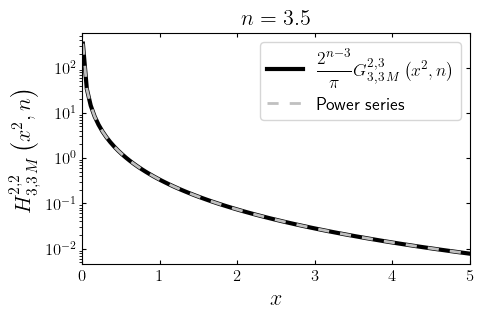

In [8]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
ls = 3
lc = 2

colora = "black"
colorn = "silver"

fig = plt.figure(figsize=(5, 3))
ges = GridSpec(1, 1)
ax1 = fig.add_subplot(ges[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.plot(x, h_pm_g, color =  colora, linestyle = "-", label = r"$\dfrac{2^{n-3}}{\pi}G^{2,3}_{3,3\,M}\left(x^2,n\right)$", linewidth = ls)
ax1.plot(x, h_pm_s, color = colorn, linestyle = (0,(4,4)), label = r"Power series", linewidth = lc)

ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$H^{2,2}_{3,3\,M}\left(x^2,n\right)$", fontsize=axis_fs)
ax1.set_title(r"$n = {0}$".format(*[n]), fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax1.set_xlim(0, 5)
#ax1.set_ylim(0, 2)
ax1.set_yscale("log")

ax1.legend(loc='upper right', fontsize = 0.8*axis_fs)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("power_series_pm.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

#### $H^{2,3}_{4,4\,\psi}\left(x^2,n\right)$ (Deflection potential)

Here, we have the power (logarithmic) series representation for the Fox $H$-function
$$
H^{2,3}_{4,4\,\psi}\left(x^2,n\right)=
H^{2,3}_{4,4} \!\left[ x^2 \left| \begin{matrix}
(1-n,2),  ( -\frac{1}{2} , 1 ),  ( -\frac{1}{2} , 1 ), (0, 1) \\
( -1 , 2 ), ( -\frac{1}{2} , 1 ),  ( -\frac{3}{2} , 1 ),  ( -\frac{3}{2} , 1)  \end{matrix} \right. \right].
$$

**For $0<x^2<1$ ($n>2$):**

$$
\begin{equation}
\dfrac{2^{n-3}}{\pi|x|}\sum_{k=0}^{\infty}\Gamma\left(\frac{n-1}{2}+k\right)\Gamma\left(\frac{n}{2}+k\right)\dfrac{x^{2k}}{((k+1)!)^2}\Bigg[2\psi_{0}(2+k) 
-\psi_{0}\left(\dfrac{n-1}{2}+k\right)-\psi_{0}\left(\dfrac{n}{2}+k\right)-\ln\left(x^2\right)\Bigg]
\end{equation}
$$
This power series can be written recursively as 
$$
\begin{equation}
\dfrac{2^{n-3}}{\pi|x|}\sum_{k=0}^{\infty}a_{1,k}x^{2k}\left[a_{2,k}-\ln\left(x^2\right)\right],
\end{equation}
$$
where
$$
\begin{align}
a_{1,k} = 
\begin{dcases}
\Gamma\left(\dfrac{n-1}{2}\right)\Gamma\left(\dfrac{n}{2}\right)\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 3)(2k + n - 2)}{4(k+1)^2}a_{1,k-1}\quad & \text{if } k>0
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{2,k} = 
\begin{dcases}
2\psi_{0}(2)-\psi_0\left(\dfrac{n-1}{2}\right) - \psi_0\left(\dfrac{n}{2}\right)\quad & \text{if } k=0 \\[3 mm]
\dfrac{2}{1+k} - \dfrac{2}{2k + n - 3} - \dfrac{2}{2k + n - 2} + a_{2,k-1} \quad & \text{if } k>0
\end{dcases}.
\end{align}
$$

<br/><br/>
**For $x^2>1$ ($n>2$ and $n\notin \mathbb{Z}$):**

$$
\begin{multline}
2\sum_{k=0}^{\infty}\dfrac{(-1)^{k}}{k!}\dfrac{\Gamma\left(n-1+k\right)\Gamma\left(\frac{n-1+k}{2}\right)}{\Gamma\left(\frac{n+k}{2}\right)}\dfrac{|x|^{-(k+n)}}{(3-n-k)^2} + \dfrac{4\Gamma(n-3)}{\sqrt{\pi}|x|^3}\left(\ln\left(\dfrac{|x|}{2}\right) + \psi_0(n-3) - \psi_0(1)\right) \\= 
\dfrac{2}{|x|^n}\sum_{k=0}^{\infty}\dfrac{\Gamma\left(n-1+2k\right)\Gamma\left(\frac{n-1}{2}+k\right)}{\Gamma\left(\frac{n}{2}+k\right)}\dfrac{x^{-2k}}{(3-n-2k)^2(2k)!}-
\dfrac{2}{|x|^{n+1}}\sum_{k=0}^{\infty}\dfrac{\Gamma\left(n+2k\right)\Gamma\left(\frac{n}{2}+k\right)}{\Gamma\left(\frac{n+1}{2}+k\right)}\dfrac{x^{-2k}}{(2-n-2k)^2(2k+1)!}\\+ 
\dfrac{4\Gamma(n-3)}{\sqrt{\pi}|x|^3}\left(\ln\left(\dfrac{|x|}{2}\right) + \psi_0(n-3) - \psi_0(1)\right),
\end{multline}
$$
which can be written recursively as 
$$
\begin{align}
\dfrac{2}{|x|^{n+1}}\sum_{k=0}^{\infty}\left(|x|a_{3,k}-a_{4,k}\right)x^{-2k} + \dfrac{4\Gamma(n-3)}{\sqrt{\pi}|x|^3}\left(\ln\left(\dfrac{|x|}{2}\right) + \psi_0(n-3) - \psi_0(1)\right)
\end{align}
$$
with
$$
\begin{align}
a_{3,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n-1\right)\Gamma\left(\frac{n-1}{2}\right)}{\Gamma\left(\frac{n}{2}\right)(3-n)^2}\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 5)^2}{2k(2k-1)}a_{3,k-1}\quad & \text{if } k>0
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{4,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n\right)\Gamma\left(\frac{n}{2}\right)}{\Gamma\left(\frac{n+1}{2}\right)(2-n)^2}\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 4)^2}{2k(2k+1)}a_{4,k-1}\quad & \text{if } k>0
\end{dcases}.
\end{align}
$$

<br/><br/>
**For $x^2>1$ ($n=3$):**

$$
\begin{align}
-4\sum_{k=0}^{\infty}\dfrac{\Gamma\left(\frac{3}{2}+k\right)}{\Gamma(1+k)}\dfrac{|x|^{-(2k+4)}}{(1+2k)^2} + \sum_{k=1}^{\infty}\dfrac{\Gamma(1+k)}{\Gamma\left(\frac{1}{2}+k\right)}\dfrac{|x|^{-(2k+3)}}{k^2} +\frac{2}{\sqrt{\pi}|x|^3}\left(\dfrac{\pi^2}{4} + \ln^2\left(\dfrac{|x|}{2}\right)\right),
\end{align}
$$
which can be written recursively as 
$$
\begin{align}
\dfrac{1}{x^{4}}\sum_{k=1}^{\infty}\left(-4a_{3,k}+|x|a_{4,k}\right)x^{-2k} -\dfrac{2\sqrt{\pi}}{x^4} + \frac{2}{\sqrt{\pi}|x|^3}\left(\dfrac{\pi^2}{4} + \ln^2\left(\dfrac{|x|}{2}\right)\right)
\end{align}
$$
with
$$
\begin{align}
a_{3,k} = 
\begin{dcases}
\dfrac{\sqrt{\pi}}{12}\quad & \text{if } k=1 \\[3 mm]
\dfrac{(1-2k)^2}{2k(1+2k)}a_{3,k-1}\quad & \text{if } k>1
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{4,k} = 
\begin{dcases}
\dfrac{2}{\sqrt{\pi}}\quad & \text{if } k=1 \\[3 mm]
\dfrac{2(k-1)^2}{k(2k-1)}a_{4,k-1}\quad & \text{if } k>1
\end{dcases}.
\end{align}
$$

<br/><br/>
**For $x^2>1$ ($n>3$ and even):**

$$
\begin{align}
\sum_{k=0}^{\infty}\dfrac{2}{(2k)!}\dfrac{\Gamma\left(n-1+2k\right)\Gamma\left(\frac{n-1}{2}+k\right)}{\Gamma\left(\frac{n}{2}+k\right)}\frac{|x|^{-(2k+n)}}{(3-n-2k)^2}-\sum_{k=(n-2)/2}^{\infty}\dfrac{\Gamma(1+2k)\Gamma(1+k)}{\Gamma\left(\frac{1}{2}+k\right)}\frac{|x|^{-(2k+3)}}{k^2(3-n+2k)!} + \dfrac{4\Gamma(n-3)}{\sqrt{\pi}|x|^3}\left(\ln\left(\dfrac{|x|}{2}\right) + \psi_0(n-3) - \psi_0(1)\right),
\end{align}
$$
which can written recursively as
$$
\begin{align}
\dfrac{2}{|x|^{n}}\sum_{k=0}^{\infty}a_{3,k}x^{-2k} -
\dfrac{1}{|x|^{3}}\sum_{k=(n-2)/2}^{\infty}a_{4,k}x^{-2k}+
\dfrac{4\Gamma(n-3)}{\sqrt{\pi}|x|^3}\left(\ln\left(\dfrac{|x|}{2}\right) + \psi_0(n-3) - \psi_0(1)\right),
\end{align}
$$
with
$$
\begin{align}
a_{3,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n-1\right)\Gamma\left(\frac{n-1}{2}\right)}{\Gamma\left(\frac{n}{2}\right)(3-n)^2}\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 5)^2}{2k(2k-1)}a_{3,k-1}\quad & \text{if } k>0
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{4,k} = 
\begin{dcases}
\dfrac{4\Gamma\left(n-1\right)\Gamma\left(\frac{n}{2}\right)}{\Gamma\left(\frac{n-1}{2}\right)(n-2)^2}\quad & \text{if } k=\frac{n}{2}-1 \\[3 mm]
\dfrac{4(k-1)^2}{(2k - n + 3)(2k - n + 2)}a_{4,k-1}\quad & \text{if } k>\frac{n}{2}-1
\end{dcases}.
\end{align}
$$

<br/><br/>
**For $x^2>1$ ($n>3$ and odd):**

$$
\begin{align}
-\sum_{k=0}^{\infty}\dfrac{2}{(2k+1)!}\dfrac{\Gamma\left(n+2k\right)\Gamma\left(\frac{n}{2}+k\right)}{\Gamma\left(\frac{n+1}{2}+k\right)}\frac{|x|^{-(2k+n+1)}}{(2-n-2k)^2}+\sum_{k=(n-3)/2}^{\infty}\dfrac{\Gamma(1+2k)\Gamma(1+k)}{\Gamma\left(\frac{1}{2}+k\right)}\frac{|x|^{-(2k+3)}}{k^2(3-n+2k)!}+ \dfrac{4\Gamma(n-3)}{\sqrt{\pi}|x|^3}\left(\ln\left(\dfrac{|x|}{2}\right) + \psi_0(n-3) - \psi_0(1)\right),
\end{align}
$$
which can written recursively as
$$
\begin{align}
-\dfrac{2}{|x|^{n+1}}\sum_{k=0}^{\infty}a_{3,k}x^{-2k} +
\dfrac{1}{|x|^{3}}\sum_{k=(n-3)/2}^{\infty}a_{4,k}x^{-2k}+
\dfrac{4\Gamma(n-3)}{\sqrt{\pi}|x|^3}\left(\ln\left(\dfrac{|x|}{2}\right) + \psi_0(n-3) - \psi_0(1)\right),
\end{align}
$$
with
$$
\begin{align}
a_{3,k} = 
\begin{dcases}
\dfrac{\Gamma\left(n\right)\Gamma\left(\frac{n}{2}\right)}{\Gamma\left(\frac{n+1}{2}\right)(2-n)^2}\quad & \text{if } k=0 \\[3 mm]
\dfrac{(2k + n - 4)^2}{2k(2k+1)}a_{3,k-1}\quad & \text{if } k>0
\end{dcases},
\qquad\qquad\text{and}\qquad\qquad
a_{4,k} = 
\begin{dcases}
\dfrac{4\Gamma\left(n-2\right)\Gamma\left(\frac{n-1}{2}\right)}{\Gamma\left(\frac{n}{2}-1\right)(n-3)^2}\quad & \text{if } k=\frac{n-3}{2} \\[3 mm]
\dfrac{4(k-1)^4}{(2k - n + 3)(2k - n + 2)}a_{4,k-1}\quad & \text{if } k>\frac{n-3}{2}
\end{dcases}.
\end{align}
$$

In [9]:
# Fox H-function power series
def DPh(x, n, tol, N_max = 1000000000):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    n: profile
    N_max : maximun number of iterations
    """
    
    sk = np.ones(4)
    ck = np.ones(4)
    
    if 0 < x**2 < 1: 
        a1k = gamma((n - 1)/2)*gamma(n/2)
        a2k = 2*digamma(2) - digamma((n - 1)/2) - digamma(n/2)
        aux = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, N_max):
            a1k *= (2*k + n - 3)*(2*k + n -2)/(4*(k + 1)**2)
            a2k += 2/(k + 1) - 2/(2*k + n - 3) - 2/(2*k + n - 2)
            
            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (2**(n-3)/(np.pi*np.abs(x)))*a1k*(a2k - np.log(x**2))*x**(2*k)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0]

    # n > 2 and non-integer
    if x**2 > 1 and type(n) != int:
        a3k = gamma(n - 1)*gamma((n - 1)/2)/(gamma(n/2)*(3 - n)**2)
        a4k = gamma(n)*gamma(n/2)/(gamma((n + 1)/2)*(2 - n)**2)
        aux = 2*(np.abs(x)*a3k - a4k)/(np.abs(x)**(n + 1))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, N_max):
            a3k *= (2*k + n - 5)**2/(2*k*(2*k - 1))
            a4k *= (2*k + n - 4)**2/(2*k*(2*k + 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = 2*((np.abs(x)*a3k - a4k)*(x**(-2*k)))/(np.abs(x)**(n + 1))
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + (4*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3))*(np.log(np.abs(x)/2) + digamma(n - 3) - digamma(1))

    # n = 3 
    if x**2 > 1 and n == 3:
        a3k = np.sqrt(np.pi)/12
        a4k = 2/np.sqrt(np.pi)
        aux = (-4*a3k + np.abs(x)*a4k)/(np.abs(x)**6)
        ck[0] = aux
        sk[0] = aux

        for k in range(2, N_max):
            a3k *= (1 - 2*k)**2/(2*k*(1 + 2*k))
            a4k *= 2*(k - 1)**2/(k*(2*k - 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = ((-4*a3k + np.abs(x)*a4k)*(x**(-2*k)))/(x**4)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] - 2*np.sqrt(np.pi)/(x**4) + 2*(np.pi**2/4 + np.log(np.abs(x)/2)**2)/(np.sqrt(np.pi)*np.abs(x)**3)

    # n > 3 and even 
    if x**2 > 1 and n > 3 and n % 2 == 0:
        a3k = gamma(n - 1)*gamma((n - 1)/2)/(gamma(n/2)*(3 - n)**2)
        a4k = 4*gamma(n - 1)*gamma(n/2)/(gamma((n - 1)/2)*(n - 2)**2)
        aux = 2*a3k/(np.abs(x)**n)
        ck[0] = aux
        sk[0] = aux

        for k in range(1, int(n/2)):
            """
            Here we perform the first summation up to n/2 - 1 (first term of the second summation).    
            """
            a3k *= (2*k + n - 5)**2/(2*k*(2*k - 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (2*a3k*(x**(-2*k)))/(np.abs(x)**n)
            ck[0] = aux
            sk[0] += aux

        ck[1::] = ck[:3]
        sk[1::] = sk[:3]
        aux = -a4k/(np.abs(x)**(n + 1)) # Here we add the first term of the second sum, evaluated at k = n/2-1
        ck[0] = aux
        sk[0] += aux

        for k in range(int(n/2), N_max):
            """
            Here we continue the first summation from n/2, and start off the second sumation from this very same value since we have alreary 
            added the first term of the sequence given for k = n/2 - 1.
            """
            a3k *= (2*k + n - 5)**2/(2*k*(2*k - 1))
            a4k *= 4*(k - 1)**2/((2*k - n + 3)*(2*k - n + 2))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = (2*a3k*(x**(-2*k)))/(np.abs(x)**n) - np.sum(a4k*(x**(-2*k)))/(np.abs(x)**3)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + (4*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3))*(np.log(np.abs(x)/2) + digamma(n - 3) - digamma(1))

    # n > 3 and odd
    if x**2 > 1 and n > 3 and n % 2 == 1:     
        a3k = gamma(n)*gamma(n/2)/(gamma((n + 1)/2)*(2 - n)**2)
        a4k = 4*gamma(n - 2)*gamma((n - 1)/2)/(gamma(n/2 - 1)*(n - 3)**2)
        aux = -2*a3k/(np.abs(x)**(n + 1))
        ck[0] = aux
        sk[0] = aux

        for k in range(1, int((n - 1)/2)):
            """
            Here we perform the first sumation up to (n - 3)/2 (first term of the second summation).    
            """
            a3k *= (2*k + n - 4)**2/(2*k*(2*k + 1))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = -2*(a3k*(x**(-2*k)))/(np.abs(x)**(n + 1))
            ck[0] = aux
            sk[0] += aux

        ck[1::] = ck[:3]
        sk[1::] = sk[:3]
        aux = a4k/(np.abs(x)**n) # Here we add the first term of the second sum, evaluated at k = (n - 3)/2
        ck[0] = aux
        sk[0] += aux

        for k in range(int((n - 1)/2), N_max):
            """
            Here we continue the first summation from (n - 1)/2, and start off the second summation from this very same value since we have 
            alreary added the first term of the sequence given for k = (n - 3)/2.
            """
            a3k *= (2*k + n - 4)**2/(2*k*(2*k + 1))
            a4k *= 4*(k - 1)**2/((2*k - n + 3)*(2*k - n + 2))

            ck[1::] = ck[:3]
            sk[1::] = sk[:3]
            aux = -2*(a3k*(x**(-2*k)))/(np.abs(x)**(n + 1)) + np.sum(a4k*(x**(-2*k)))/(np.abs(x)**3)
            ck[0] = aux
            sk[0] += aux

            cond1 = np.abs(ck[0]/sk[1])
            cond2 = np.abs(ck[1]/sk[2])
            cond3 = np.abs(ck[2]/sk[3])

            if cond1 <= tol and cond2 <= tol and cond3 <= tol:
                break
                
        return k, sk[0] + (4*gamma(n - 3)/(np.sqrt(np.pi)*np.abs(x)**3))*(np.log(np.abs(x)/2) + digamma(n - 3) - digamma(1))

In [10]:
points = 100
tol = 1e-15

n = 4

x = np.linspace(0.01, 5, points)

h_dp_s = np.zeros(points)
h_dp_g = np.zeros(points)

for i in range(points):
    h_dp_g[i] = DPg(x[i], n) # Meijer G-function
    _, dpi = DPh(x[i], n, tol) # Fox H-function power series
    h_dp_s[i] = dpi

"""
Relative porcentual difference: 
The biggest difference tends to happen close to x = 1, where the Fox H-function has a discontinuity.
"""
print(np.amax(np.abs(100*(h_dp_g - h_dp_s)/h_dp_g)))

7.416810597143473e-12


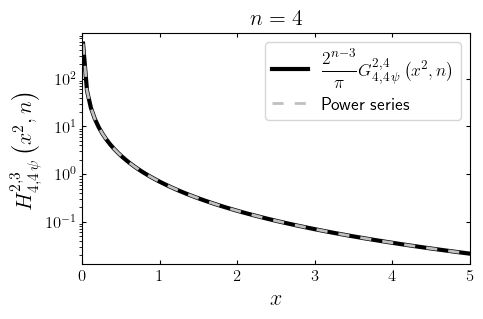

In [11]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
ls = 3
lc = 2

colora = "black"
colorn = "silver"

fig = plt.figure(figsize=(5, 3))
ges = GridSpec(1, 1)
ax1 = fig.add_subplot(ges[0,0])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

ax1.plot(x, h_dp_g, color =  colora, linestyle = "-", label = r"$\dfrac{2^{n-3}}{\pi}G^{2,4}_{4,4\,\psi}\left(x^2,n\right)$", linewidth = ls)
ax1.plot(x, h_dp_s, color = colorn, linestyle = (0,(4,4)), label = r"Power series", linewidth = lc)

ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$H^{2,3}_{4,4\,\psi}\left(x^2,n\right)$", fontsize=axis_fs)
ax1.set_title(r"$n = {0}$".format(*[n]), fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax1.set_xlim(0, 5)
#ax1.set_ylim(0, 2)
ax1.set_yscale("log")

ax1.legend(loc='upper right', fontsize = 0.8*axis_fs)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("power_series_dp.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

## "Fast" calculation

The "fast" canculations is provied only for $n=3$ (NFW), $n=7/2$ (sNFW), and $n=4$ (Hernquist).

#### $H^{2,1}_{2,2\,\Sigma}\left(x^2,n\right)$ (Surface mass density)

In [12]:
# "Fast" computation (Surface mass density)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Coefficients ak

def SMDh_coef(n, N):
    """
    n: profile
    N : number of terms to be evaluated
    """
    
    ak = np.zeros((4,N))

    ak[0][0] = gamma((n - 1)/2)*gamma(n/2)
    ak[1][0] = 2*digamma(1) - digamma((n - 1)/2) - digamma(n/2)

    ak[2][0] = gamma(n - 1)*gamma((n - 1)/2)/gamma(n/2)
    ak[3][0] = gamma(n)*gamma(n/2)/gamma((n + 1)/2)

    for i in range(1, N):
        ak[0][i] = ak[0][i - 1]*(2*i + n - 3)*(2*i + n -2)/(4*i**2)
        ak[1][i] = ak[1][i - 1] + 2/i - 2/(2*i + n - 3) - 2/(2*i + n -2)
    
        ak[2][i] = ak[2][i - 1]*(2*i + n - 3)**2/(2*i*(2*i - 1))
        ak[3][i] = ak[3][i - 1]*(2*i + n - 2)**2/(2*i*(2*i + 1))

    return ak 

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Power series

def SMDh_f(x, n, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    n: profile
    ak: coefficients SMDh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (2**(n-3)/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (2**(n-3)/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (2**(n-3)/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return 0.5*np.sum((np.abs(x)*ak[2] - ak[3])*(x**(-2*k)))/(np.abs(x)**(n + 1))
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return 0.5*np.sum((np.abs(x)*ak[2][:201] - ak[3][:201])*(x**(-2*k)))/(np.abs(x)**(n + 1))
    if x**2 >= 1.5:
        k = k[:51]
        return 0.5*np.sum((np.abs(x)*ak[2][:51] - ak[3][:51])*(x**(-2*k)))/(np.abs(x)**(n + 1))
    if x**2 == 1:
        return gamma(n-1)**2/(2**(n - 1)*gamma(n - 1/2))

In [13]:
points = 100
N = 1500

x = np.linspace(0.01, 5, points)

h_smd_nfw = np.zeros(points)
h_smd_nfw_g = np.zeros(points)
h_smd_snfw = np.zeros(points)
h_smd_snfw_g = np.zeros(points)
h_smd_h = np.zeros(points)
h_smd_h_g = np.zeros(points)

ak_nfw = SMDh_coef(3, N)
ak_snfw = SMDh_coef(3.5, N)
ak_h = SMDh_coef(4, N)

k = np.arange(0, N, 1)
print(k)

for i in range(points):
    h_smd_nfw_g[i] = SMDg(x[i], 3)
    h_smd_nfw[i] = SMDh_f(x[i], 3, ak_nfw, k)
    h_smd_snfw_g[i] = SMDg(x[i], 3.5)
    h_smd_snfw[i] = SMDh_f(x[i], 3.5, ak_snfw, k)
    h_smd_h_g[i] = SMDg(x[i], 4)
    h_smd_h[i] = SMDh_f(x[i], 4, ak_h, k)

[   0    1    2 ... 1497 1498 1499]


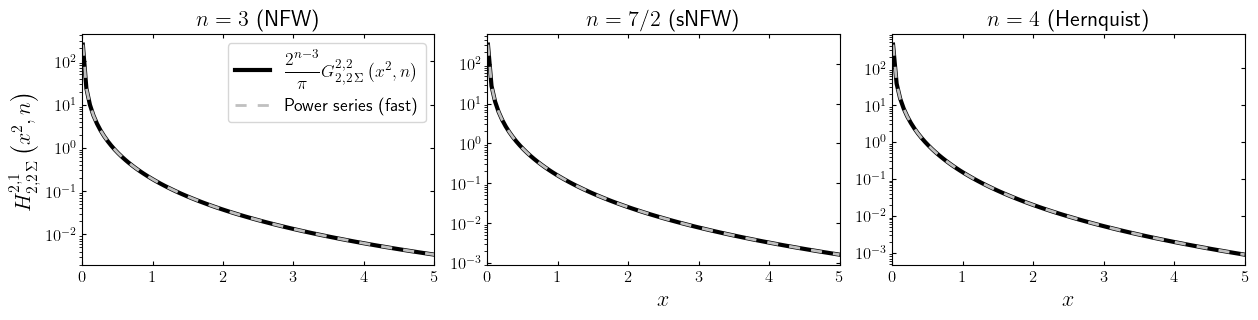

In [14]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
lc = 2

colora = "black"
colorn = "silver"

fig = plt.figure(figsize=(15, 3))
ges = GridSpec(1, 3,hspace=0.2, wspace=0.15)

ax1 = fig.add_subplot(ges[0,0])
ax2 = fig.add_subplot(ges[0,1])
ax3 = fig.add_subplot(ges[0,2])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# NFW

ax1.plot(x, h_smd_nfw_g, color =  colora, linestyle = "-", label = r"$\dfrac{2^{n-3}}{\pi}G^{2,2}_{2,2\,\Sigma}\left(x^2,n\right)$", linewidth = ls)
ax1.plot(x, h_smd_nfw, color = colorn, linestyle = (0,(4,4)), label = r"Power series (fast)", linewidth = lc)

#ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$H^{2,1}_{2,2\,\Sigma}\left(x^2,n\right)$", fontsize=axis_fs)
ax1.set_title(r"$n = 3$ (NFW)", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax1.set_xlim(0, 5)
#ax1.set_ylim(0, 2)
ax1.set_yscale("log")

ax1.legend(loc='upper right', fontsize = 0.8*axis_fs)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# sNFW

ax2.plot(x, h_smd_snfw_g, color =  colora, linestyle = "-", label = r"Analytical", linewidth = ls)
ax2.plot(x, h_smd_snfw, color = colorn, linestyle= (0,(4,4)), label = r"Numerical", linewidth = lc)

ax2.set_xlabel(r"$x$", fontsize=axis_fs)
#ax2.set_ylabel(r"$H^{2,2}_{3,3\,M}\left(x^2,n\right)$", fontsize=axis_fs)
ax2.set_title(r"$n=7/2$ (sNFW)", fontsize=axis_fs)
ax2.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax2.set_xlim(0, 5)
#ax2.set_ylim(0, 3.5)
ax2.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# hernquist

ax3.plot(x, h_smd_h_g, color =  colora, linestyle = "-", label = r"sNFW", linewidth = ls)
ax3.plot(x, h_smd_h, color = colorn, linestyle= (0,(4,4)), label = r"Numerical", linewidth = lc)

ax3.set_xlabel(r"$x$", fontsize=axis_fs)
#ax3.set_ylabel(r"$H^{2,2}_{3,3\,M}\left(x^2,n\right)$", fontsize=axis_fs)
ax3.set_title(r"$n=4$ (Hernquist)", fontsize=axis_fs)
ax3.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax3.yaxis.set_major_locator(ticker.MultipleLocator(0.3))
ax3.set_xlim(0, 5)
#ax3.set_ylim(0, 1.5)
ax3.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("fast_power_series_smd.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

#### $H^{2,2}_{3,3\,M}\left(x^2,n\right)$ (Projected mass)

In [15]:
# "Fast" computation (Projected mass)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Coefficients ak

def PMh_coef(n, N):
    """
    n: profile
    N : number of terms to be evaluated
    """
    
    ak = np.zeros((4,N))
    
    ak[0][0] = gamma((n - 1)/2)*gamma(n/2)
    ak[1][0] = 1 + 2*digamma(1) - digamma((n - 1)/2) - digamma(n/2)
    
    if n == 3:
        ak[2][0] = np.sqrt(np.pi)

        ak[0][1] = ak[0][0]*3/4
        ak[1][1] = ak[1][0] + 1/2 - 2/3
        ak[2][1] = np.sqrt(np.pi)/2
        ak[3][1] = 2/np.sqrt(np.pi)

        for k in range(2, N):
            ak[0][k] = ak[0][k - 1]*(2*k)*(2*k + 1)/(4*k*(k + 1))
            ak[1][k] = ak[1][k - 1] + 1/(k + 1) - 2/(2*k + 1)
    
            ak[2][k] = ak[2][k - 1]*(2*k - 1)/(2*k)
            ak[3][k] = ak[3][k - 1]*2*(k - 1)/(2*k - 1)

    if n == 3.5:
        ak[2][0] = -2*gamma(5/2)*gamma(5/4)/(gamma(7/4))
        ak[3][0] = -2*gamma(7/2)*gamma(7/4)/(3*gamma(9/4))

        for k in range(1, N):
            ak[0][k] = ak[0][k - 1]*(2*k + 0.5)*(2*k + 1.5)/(4*k*(k + 1))
            ak[1][k] = ak[1][k - 1] + 1/k + 1/(k + 1) - 2/(2*k + 0.5) - 2/(2*k + 1.5)
            
            ak[2][k] = ak[2][k - 1]*(2*k + 0.5)*(2*k - 1.5)/(2*k*(2*k - 1))
            ak[3][k] = ak[3][k - 1]*(2*k + 1.5)*(2*k - 0.5)/(2*k*(2*k + 1))

    if n == 4:
        ak[2][0] = -np.sqrt(np.pi)

        ak[0][1] = ak[0][0]*3/2
        ak[1][1] = ak[1][0] + 1 - 2/3
        ak[2][1] = ak[2][0]*3/2
        ak[3][1] = 4/np.sqrt(np.pi)
         
        for k in range(2, N):
            ak[0][k] = ak[0][k - 1]*(2*k + 1)/(2*k)
            ak[1][k] = ak[1][k - 1] + 1/k - 2/(2*k + 1)
    
            ak[2][k] = ak[2][k - 1]*(2*k + 1)/(2*k)
            ak[3][k] = ak[3][k - 1]*2*k/(2*k - 1)
    return ak 

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Power series
    
# NFW
def PMh_f_nfw(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients PMh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """

    aux = 2*np.log(np.abs(x)/2)/(np.sqrt(np.pi)*np.abs(x)**3)
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return np.sum((ak[2] - np.abs(x)*ak[3])*(x**(-2*k)))/(x**4) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return np.sum((ak[2][:201] - np.abs(x)*ak[3][:201])*(x**(-2*k)))/(x**4) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return np.sum((ak[2][:51] - np.abs(x)*ak[3][:51])*(x**(-2*k)))/(x**4) + aux

# super-NFW
def PMh_f_snfw(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients PMh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """

    aux = 2/np.abs(x)**3
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return np.sum((np.abs(x)*ak[2] - ak[3])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return np.sum((np.abs(x)*ak[2][:201] - ak[3][:201])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return np.sum((np.abs(x)*ak[2][:51] - ak[3][:51])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux

# Hernquist
def PMh_f_h(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients PMh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """

    aux = 2/(np.sqrt(np.pi)*np.abs(x)**3)
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return np.sum((ak[2] + np.abs(x)*ak[3])*(x**(-2*k)))/(np.abs(x)**4) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return np.sum((ak[2][:201] + np.abs(x)*ak[3][:201])*(x**(-2*k)))/(np.abs(x)**4) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return np.sum((ak[2][:51] + np.abs(x)*ak[3][:51])*(x**(-2*k)))/(np.abs(x)**4) + aux

In [16]:
points = 100
N = 1500

x = np.linspace(0.01, 5, points)

h_pm_nfw = np.zeros(points)
h_pm_nfw_g = np.zeros(points)
h_pm_snfw = np.zeros(points)
h_pm_snfw_g = np.zeros(points)
h_pm_h = np.zeros(points)
h_pm_h_g = np.zeros(points)

ak_nfw = PMh_coef(3, N)
ak_snfw = PMh_coef(3.5, N)
ak_h = PMh_coef(4, N)

k = np.arange(0, N, 1)

for i in range(points):
    h_pm_nfw_g[i] = PMg(x[i], 3)
    h_pm_nfw[i] = PMh_f_nfw(x[i], ak_nfw, k)
    h_pm_snfw_g[i] = PMg(x[i], 3.5)
    h_pm_snfw[i] = PMh_f_snfw(x[i], ak_snfw, k)
    h_pm_h_g[i] = PMg(x[i], 4)
    h_pm_h[i] = PMh_f_h(x[i], ak_h, k)

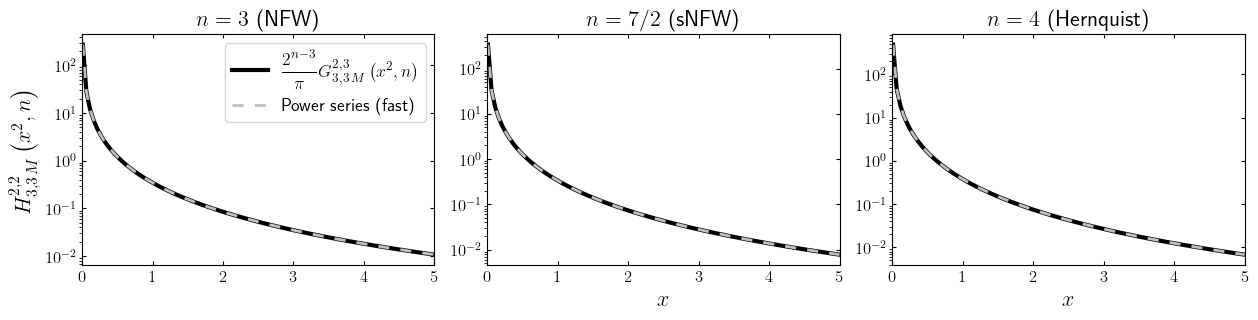

In [17]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
ls = 3
lc = 2

colora = "black"
colorn = "silver"

fig = plt.figure(figsize=(15, 3))
ges = GridSpec(1, 3,hspace=0.2, wspace=0.15)

ax1 = fig.add_subplot(ges[0,0])
ax2 = fig.add_subplot(ges[0,1])
ax3 = fig.add_subplot(ges[0,2])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# NFW

ax1.plot(x, h_pm_nfw_g, color =  colora, linestyle = "-", label = r"$\dfrac{2^{n-3}}{\pi}G^{2,3}_{3,3\,M}\left(x^2,n\right)$", linewidth = ls)
ax1.plot(x, h_pm_nfw, color = colorn, linestyle = (0,(4,4)), label = r"Power series (fast)", linewidth = lc)

#ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$H^{2,2}_{3,3\,M}\left(x^2,n\right)$", fontsize=axis_fs)
ax1.set_title(r"$n = 3$ (NFW)", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax1.set_xlim(0, 5)
#ax1.set_ylim(0, 2)
ax1.set_yscale("log")

ax1.legend(loc='upper right', fontsize = 0.8*axis_fs)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# sNFW

ax2.plot(x, h_pm_snfw_g, color =  colora, linestyle = "-", label = r"Analytical", linewidth = ls)
ax2.plot(x, h_pm_snfw, color = colorn, linestyle= (0,(4,4)), label = r"Numerical", linewidth = lc)

ax2.set_xlabel(r"$x$", fontsize=axis_fs)
#ax2.set_ylabel(r"$H^{2,2}_{3,3\,M}\left(x^2,n\right)$", fontsize=axis_fs)
ax2.set_title(r"$n=7/2$ (sNFW)", fontsize=axis_fs)
ax2.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax2.set_xlim(0, 5)
#ax2.set_ylim(0, 3.5)
ax2.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Hernquist

ax3.plot(x, h_pm_h_g, color =  colora, linestyle = "-", label = r"sNFW", linewidth = ls)
ax3.plot(x, h_pm_h, color = colorn, linestyle= (0,(4,4)), label = r"Numerical", linewidth = lc)

ax3.set_xlabel(r"$x$", fontsize=axis_fs)
#ax3.set_ylabel(r"$H^{2,2}_{3,3\,M}\left(x^2,n\right)$", fontsize=axis_fs)
ax3.set_title(r"$n=4$ (Hernquist)", fontsize=axis_fs)
ax3.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax3.yaxis.set_major_locator(ticker.MultipleLocator(0.3))
ax3.set_xlim(0, 5)
#ax3.set_ylim(0, 1.5)
ax3.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("fast_power_series_pm.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()

#### $H^{2,3}_{4,4\,\psi}\left(x^2,n\right)$ (Deflection potential)

In [18]:
# "Fast" computation (Deflection potential)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Coefficients ak

def DPh_coef(n, N):
    """
    n: profile
    N : number of terms to be evaluated
    """
    
    ak = np.zeros((4,N))

    ak[0][0] = gamma((n - 1)/2)*gamma(n/2)
    ak[1][0] = 2*digamma(2) - digamma((n - 1)/2) - digamma(n/2)
    
    if n == 3:
        ak[2][0] = np.sqrt(np.pi)/2

        ak[0][1] = ak[0][0]*3/8
        ak[1][1] = ak[1][0] - 2/3
        ak[2][1] = np.sqrt(np.pi)/12
        ak[3][1] = 2/np.sqrt(np.pi)

        for k in range(2, N):
            ak[0][k] = ak[0][k - 1]*(2*k)*(2*k + 1)/(4*(k + 1)**2)
            ak[1][k] = ak[1][k - 1] + 2/(k + 1) - 1/k - 2/(2*k + 1)
    
            ak[2][k] = ak[2][k - 1]*(1 - 2*k)**2/(2*k*(1 + 2*k))
            ak[3][k] = ak[3][k - 1]*2*(k - 1)**2/(k*(2*k - 1))

    if n == 3.5:
        ak[2][0] = 4*gamma(5/2)*gamma(5/4)/(gamma(7/4))
        ak[3][0] = 4*gamma(7/2)*gamma(7/4)/(9*gamma(9/4))

        for k in range(1, N):
            ak[0][k] = ak[0][k - 1]*(2*k + 0.5)*(2*k + 1.5)/(4*(k + 1)**2)
            ak[1][k] = ak[1][k - 1] + 2/(k + 1) - 2/(2*k + 0.5) - 2/(2*k + 1.5)
            
            ak[2][k] = ak[2][k - 1]*(2*k - 1.5)**2/(2*k*(2*k - 1))
            ak[3][k] = ak[3][k - 1]*(2*k - 0.5)**2/(2*k*(2*k + 1))

    if n == 4:
        ak[2][0] = np.sqrt(np.pi)

        ak[0][1] = ak[0][0]*3/4
        ak[1][1] = ak[1][0] + 1/2 - 2/3
        ak[2][1] = ak[2][0]*1/2
        ak[3][1] = 4/np.sqrt(np.pi)
        
        for k in range(2, N):
            ak[0][k] = ak[0][k - 1]*(2*k + 1)/(2*(k + 1))
            ak[1][k] = ak[1][k - 1] + 1/(k + 1) - 2/(2*k + 1)
    
            ak[2][k] = ak[2][k - 1]*(2*k - 1)/(2*k)
            ak[3][k] = ak[3][k - 1]*2*(k - 1)/(2*k - 1)
    return ak 

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Power series

# NFW
def DPh_f_nfw(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients DPh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """

    aux = 2*(np.pi**2/4 + np.log(np.abs(x)/2)**2)/(np.sqrt(np.pi)*np.abs(x)**3)
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (1/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return np.sum((-4*ak[2] + np.abs(x)*ak[3])*(x**(-2*k)))/(x**4) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return np.sum((-4*ak[2][:201] + np.abs(x)*ak[3][:201])*(x**(-2*k)))/(x**4) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return np.sum((-4*ak[2][:51] + np.abs(x)*ak[3][:51])*(x**(-2*k)))/(x**4) + aux

# super-NFW
def DPh_f_snfw(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients DPh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """

    aux = (4/(np.abs(x)**3))*(np.log(np.abs(x)/2) + digamma(0.5) - digamma(1))
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (2**(1/2)/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return 2*np.sum((np.abs(x)*ak[2] - ak[3])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return 2*np.sum((np.abs(x)*ak[2][:201] - ak[3][:201])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return 2*np.sum((np.abs(x)*ak[2][:51] - ak[3][:51])*(x**(-2*k)))/(np.abs(x)**(4.5)) + aux

# Hernquist
def DPh_f_h(x, ak, k):
    """
    0 < x^2 < 1 and x^2 > 1: dimensionless radius (position) 
    ak: coefficients DPh_coef
    k: lisst of integers of size N, which goes form 0 up to N-1. Here, N is the number of terms used in the summation
    """

    aux = (4/(np.sqrt(np.pi)*np.abs(x)**3))*np.log(np.abs(x)/2)
    
    if 0 < x**2 < 0.5:
        k = k[:51]
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0][:51]*x**(2*k)*(ak[1][:51] - np.log(x**2)))
    if 0.5 <= x**2 < 0.9: 
        k = k[:201]
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0][:201]*x**(2*k)*(ak[1][:201] - np.log(x**2)))
    if 0.9 <= x**2 < 1:  
        return (2/(np.pi*np.abs(x)))*np.sum(ak[0]*x**(2*k)*(ak[1] - np.log(x**2)))
    
    if 1 < x**2 < 1.1:
        return np.sum((2*ak[2] - np.abs(x)*ak[3])*(x**(-2*k)))/(np.abs(x)**4) + aux
    if 1.1 <= x**2 < 1.5:
        k = k[:201]
        return np.sum((2*ak[2][:201] - np.abs(x)*ak[3][:201])*(x**(-2*k)))/(np.abs(x)**4) + aux
    if x**2 >= 1.5:
        k = k[:51]
        return np.sum((2*ak[2][:51] - np.abs(x)*ak[3][:51])*(x**(-2*k)))/(np.abs(x)**4) + aux

In [19]:
points = 100
N = 1500

x = np.linspace(0.01, 5, points)

h_dp_nfw = np.zeros(points)
h_dp_nfw_g = np.zeros(points)
h_dp_snfw = np.zeros(points)
h_dp_snfw_g = np.zeros(points)
h_dp_h = np.zeros(points)
h_dp_h_g = np.zeros(points)

ak_nfw = DPh_coef(3, N)
ak_snfw = DPh_coef(3.5, N)
ak_h = DPh_coef(4, N)

k = np.arange(0, N, 1)

for i in range(points):
    h_dp_nfw_g[i] = DPg(x[i], 3)
    h_dp_nfw[i] = DPh_f_nfw(x[i], ak_nfw, k)
    h_dp_snfw_g[i] = DPg(x[i], 3.5)
    h_dp_snfw[i] = DPh_f_snfw(x[i], ak_snfw, k)
    h_dp_h_g[i] = DPg(x[i], 4)
    h_dp_h[i] = DPh_f_h(x[i], ak_h, k)

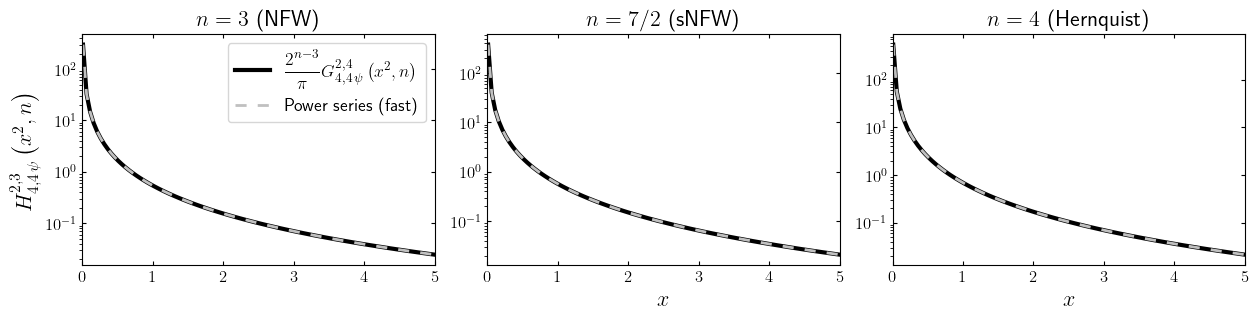

In [20]:
# Latex have to be installed, otherwise comment the first two lines.
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('text', usetex = True)

axis_fs = 16
ticks_s = 12
ls = 3
lc = 2

colora = "black"
colorn = "silver"

fig = plt.figure(figsize=(15, 3))
ges = GridSpec(1, 3,hspace=0.2, wspace=0.15)

ax1 = fig.add_subplot(ges[0,0])
ax2 = fig.add_subplot(ges[0,1])
ax3 = fig.add_subplot(ges[0,2])

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# NFW

ax1.plot(x, h_dp_nfw_g, color =  colora, linestyle = "-", label = r"$\dfrac{2^{n-3}}{\pi}G^{2,4}_{4,4\,\psi}\left(x^2,n\right)$", linewidth = ls)
ax1.plot(x, h_dp_nfw, color = colorn, linestyle = (0,(4,4)), label = r"Power series (fast)", linewidth = lc)

#ax1.set_xlabel(r"$x$", fontsize=axis_fs)
ax1.set_ylabel(r"$H^{2,3}_{4,4\,\psi}\left(x^2,n\right)$", fontsize=axis_fs)
ax1.set_title(r"$n = 3$ (NFW)", fontsize=axis_fs)
ax1.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.4))
ax1.set_xlim(0, 5)
#ax1.set_ylim(0, 2)
ax1.set_yscale("log")

ax1.legend(loc='upper right', fontsize = 0.8*axis_fs)

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# sNFW

ax2.plot(x, h_dp_snfw_g, color =  colora, linestyle = "-", label = r"Analytical", linewidth = ls)
ax2.plot(x, h_dp_snfw, color = colorn, linestyle= (0,(4,4)), label = r"Numerical", linewidth = lc)

ax2.set_xlabel(r"$x$", fontsize=axis_fs)
#ax2.set_ylabel(r"$H^{2,2}_{3,3\,M}\left(x^2,n\right)$", fontsize=axis_fs)
ax2.set_title(r"$n=7/2$ (sNFW)", fontsize=axis_fs)
ax2.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.7))
ax2.set_xlim(0, 5)
#ax2.set_ylim(0, 3.5)
ax2.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
# Hernquist

ax3.plot(x, h_dp_h_g, color =  colora, linestyle = "-", label = r"sNFW", linewidth = ls)
ax3.plot(x, h_dp_h, color = colorn, linestyle= (0,(4,4)), label = r"Numerical", linewidth = lc)

ax3.set_xlabel(r"$x$", fontsize=axis_fs)
#ax3.set_ylabel(r"$H^{2,2}_{3,3\,M}\left(x^2,n\right)$", fontsize=axis_fs)
ax3.set_title(r"$n=4$ (Hernquist)", fontsize=axis_fs)
ax3.tick_params(labelsize=ticks_s, top = True, bottom = True, left = True, right = True, labelbottom = True, labelleft = True, direction = "in", length = 3, width = 0.8)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax3.yaxis.set_major_locator(ticker.MultipleLocator(0.3))
ax3.set_xlim(0, 5)
#ax3.set_ylim(0, 1.5)
ax3.set_yscale("log")

#HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

#plt.savefig("fast_power_series_dp.pdf", bbox_inches='tight', dpi = 300, transparent=True)
plt.show()